# Fast soft active particle simulations 

This notebook is a corrected, faster version of the soft active particle model notebook.

Main changes:

1. The long simulation no longer stores the full particle history.
2. The parameter sweep also stores only summary observables and final snapshots.
3. The expensive per-step Python loops are moved into a `numba`-compiled function.
4. The alignment torque uses the paper-consistent average angular mismatch instead of only aligning to the mean orientation vector.
5. Default large-run settings are closer to the paper: `dt = 0.1`, `save_every = 128`, `N = 400`.

For long runs, use this notebook instead of the animation-heavy notebook. Make animations only by rerunning a short selected case with a large `snapshot_every`.

## 1. Imports

`numba` is the important speed-up. The first run is slower because the function has to compile. After that, the same simulation should be much faster than pure Python.

If `numba` is missing, install it in a notebook cell with:

```python
%pip install numba
```

Then restart the kernel and run the notebook again.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace, asdict
from time import perf_counter
from pathlib import Path

try:
    from numba import njit
    NUMBA_AVAILABLE = True
except ImportError:
    NUMBA_AVAILABLE = False
    raise ImportError(
        "This fast notebook needs numba. Install it with: %pip install numba, "
        "then restart the kernel."
    )

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = False

## 2. Model parameters

These defaults are chosen for paper-style simulations, not for tiny debugging runs.

The paper-scale run is approximately:

```python
N = 400
steps = 100_000_000
dt = 0.1
save_every = 128
```

Do **not** start there. First benchmark your machine with `steps = 20_000` or `100_000`.

In [2]:
@dataclass
class ModelParameters:
    N: int = 400
    dt: float = 0.1
    steps: int = 1_000_000
    save_every: int = 128

    # Paper-style dimensionless parameters
    lambda_s: float = 0.07
    lambda_a: float = 0.30
    lambda_n: float = 0.03
    lambda_Fin: float = 0.3
    lambda_Tin: float = 3.0

    # Fixed dimensionless constants
    a_bar: float = 1.0
    radius_std: float = 0.1
    k_rep: float = 1.0
    zeta: float = 1.0
    chi: float = 1.0

    # Neighbor cutoff from the paper
    neighbor_cutoff: float = 2.7

    # Initial condition
    initial_width_particles: int = 20
    initial_spacing: float = 2.0
    position_jitter: float = 0.05
    initial_angle_noise: float = np.pi / 4

    seed: int = 1

    @property
    def total_time(self):
        return self.steps * self.dt

## 3. Initialization and small helper functions

In [3]:
def initialize_particles(params: ModelParameters):
    """Create the initial particle positions, angles and radii."""
    rng = np.random.default_rng(params.seed)
    N = params.N

    radii = rng.normal(loc=params.a_bar, scale=params.radius_std, size=N)
    radii = np.clip(radii, 0.7 * params.a_bar, 1.3 * params.a_bar)

    width = params.initial_width_particles
    height = int(np.ceil(N / width))

    positions = []
    for row in range(height):
        for col in range(width):
            if len(positions) >= N:
                break
            positions.append([col * params.initial_spacing, row * params.initial_spacing])

    positions = np.asarray(positions, dtype=np.float64)
    positions -= positions.mean(axis=0)
    positions += params.position_jitter * rng.normal(size=positions.shape)

    angles = rng.uniform(
        low=-params.initial_angle_noise,
        high=params.initial_angle_noise,
        size=N,
    ).astype(np.float64)

    return positions, angles, radii.astype(np.float64)


def unit_vectors(angles):
    return np.column_stack((np.cos(angles), np.sin(angles)))


def final_boundary_information_python(positions, cutoff):
    """Simple Python version used only for plotting the final snapshot."""
    N = len(positions)
    is_boundary = np.zeros(N, dtype=bool)

    for i in range(N):
        rel = positions - positions[i]
        dist = np.linalg.norm(rel, axis=1)
        mask = (dist < cutoff) & (dist > 1e-12)

        if not np.any(mask):
            is_boundary[i] = True
            continue

        angles = np.sort(np.mod(np.arctan2(rel[mask, 1], rel[mask, 0]), 2 * np.pi))
        gaps = np.diff(np.concatenate([angles, [angles[0] + 2 * np.pi]]))
        is_boundary[i] = gaps.max() >= np.pi

    return is_boundary

## 4. Fast compiled simulation core

This is the cell that makes the notebook much faster.

Notes:

- It stores only summary values every `save_every` steps.
- It still computes the neighbor information every step.
- The alignment torque is

\[
T_i^{align} = \lambda_a \langle \Delta \psi_{ij} \rangle_j,
\]

where the average is over neighbors.

The first time you run this cell and then start a simulation, `numba` compiles the function. That first run is slower; later runs use the compiled machine code.

In [4]:
@njit
def _signed_angle_difference(target, current):
    return np.arctan2(np.sin(target - current), np.cos(target - current))


@njit
def _run_summary_core(
    positions,
    angles,
    radii,
    steps,
    dt,
    save_every,
    lambda_s,
    lambda_a,
    lambda_n,
    lambda_Fin,
    lambda_Tin,
    k_rep,
    zeta,
    chi,
    a_bar,
    neighbor_cutoff,
    seed,
    progress_every,
):
    """
    Fast numba-compiled simulation loop.

    This uses a direct pair loop. For N=400 this is usually much faster than
    pure Python and simple enough to be robust.
    """
    np.random.seed(seed)

    N = positions.shape[0]
    n_saves = steps // save_every + 1

    time = np.empty(n_saves)
    phi = np.empty(n_saves)
    angular_order = np.empty(n_saves)
    com = np.empty((n_saves, 2))
    rms_radius = np.empty(n_saves)

    forces = np.empty((N, 2))
    torques = np.empty(N)

    # Dense temporary storage for neighbor angles used for the boundary test.
    # N=400 -> this is small. It avoids Python lists inside the loop.
    neighbor_angles = np.empty((N, N))
    neighbor_counts = np.empty(N, dtype=np.int64)

    align_sum = np.empty(N)
    align_count = np.empty(N, dtype=np.int64)

    final_boundary = np.zeros(N, dtype=np.bool_)
    cutoff2 = neighbor_cutoff * neighbor_cutoff
    noise_amp = np.sqrt(2.0 * lambda_n / dt)

    save_index = 0

    for step in range(steps + 1):
        # Save current summary before doing the next update.
        if step % save_every == 0:
            sx = 0.0
            sy = 0.0
            cx = 0.0
            cy = 0.0

            for i in range(N):
                sx += np.cos(angles[i])
                sy += np.sin(angles[i])
                cx += positions[i, 0]
                cy += positions[i, 1]

            sx /= N
            sy /= N
            cx /= N
            cy /= N

            tangential_sum = 0.0
            rr_sum = 0.0
            for i in range(N):
                rx = positions[i, 0] - cx
                ry = positions[i, 1] - cy
                r = np.sqrt(rx * rx + ry * ry)
                rr_sum += r * r

                if r > 1e-12:
                    ux = np.cos(angles[i])
                    uy = np.sin(angles[i])
                    # Tangential unit vector around the center of mass.
                    tx = -ry / r
                    ty = rx / r
                    tangential_sum += ux * tx + uy * ty

            time[save_index] = step * dt
            phi[save_index] = np.sqrt(sx * sx + sy * sy)
            angular_order[save_index] = abs(tangential_sum / N)
            com[save_index, 0] = cx
            com[save_index, 1] = cy
            rms_radius[save_index] = np.sqrt(rr_sum / N)
            save_index += 1

        if step == steps:
            break

        if progress_every > 0 and step > 0 and step % progress_every == 0:
            print("step", step, "of", steps)

        # Reset arrays and add self propulsion.
        for i in range(N):
            forces[i, 0] = lambda_s * np.cos(angles[i])
            forces[i, 1] = lambda_s * np.sin(angles[i])
            torques[i] = 0.0
            neighbor_counts[i] = 0
            align_sum[i] = 0.0
            align_count[i] = 0
            final_boundary[i] = False

        # Pair loop: neighbors, repulsion, and alignment mismatch sums.
        for i in range(N - 1):
            xi = positions[i, 0]
            yi = positions[i, 1]

            for j in range(i + 1, N):
                dx = xi - positions[j, 0]
                dy = yi - positions[j, 1]
                d2 = dx * dx + dy * dy

                if d2 < cutoff2:
                    d = np.sqrt(d2)
                    if d > 1e-12:
                        ci = neighbor_counts[i]
                        neighbor_angles[i, ci] = np.arctan2(-dy, -dx)
                        neighbor_counts[i] = ci + 1

                        cj = neighbor_counts[j]
                        neighbor_angles[j, cj] = np.arctan2(dy, dx)
                        neighbor_counts[j] = cj + 1

                        align_sum[i] += _signed_angle_difference(angles[j], angles[i])
                        align_sum[j] += _signed_angle_difference(angles[i], angles[j])
                        align_count[i] += 1
                        align_count[j] += 1

                        preferred_distance = radii[i] + radii[j]
                        if d < preferred_distance:
                            overlap = preferred_distance - d
                            fx = k_rep * overlap * dx / d
                            fy = k_rep * overlap * dy / d
                            forces[i, 0] += fx
                            forces[i, 1] += fy
                            forces[j, 0] -= fx
                            forces[j, 1] -= fy

        # Boundary criterion, inward torque, alignment torque, and noise.
        for i in range(N):
            if align_count[i] > 0:
                torques[i] += lambda_a * align_sum[i] / align_count[i]

            count = neighbor_counts[i]
            theta_out = 2.0 * np.pi
            inward_angle = 0.0

            if count > 0:
                # Convert to [0, 2pi).
                for k in range(count):
                    a = neighbor_angles[i, k]
                    a = a % (2.0 * np.pi)
                    neighbor_angles[i, k] = a

                # Insertion sort. Neighbor counts are small, so this is cheap.
                for k in range(1, count):
                    key = neighbor_angles[i, k]
                    m = k - 1
                    while m >= 0 and neighbor_angles[i, m] > key:
                        neighbor_angles[i, m + 1] = neighbor_angles[i, m]
                        m -= 1
                    neighbor_angles[i, m + 1] = key

                max_gap = -1.0
                max_index = 0
                for k in range(count - 1):
                    gap = neighbor_angles[i, k + 1] - neighbor_angles[i, k]
                    if gap > max_gap:
                        max_gap = gap
                        max_index = k

                wrap_gap = neighbor_angles[i, 0] + 2.0 * np.pi - neighbor_angles[i, count - 1]
                if wrap_gap > max_gap:
                    max_gap = wrap_gap
                    max_index = count - 1

                theta_out = max_gap
                outward_angle = neighbor_angles[i, max_index] + theta_out / 2.0
                inward_angle = (outward_angle + np.pi) % (2.0 * np.pi)

            if theta_out >= np.pi:
                final_boundary[i] = True
                boundary_strength = theta_out - np.pi

                # Same convention as the original notebook: boundary force along the particle orientation,
                # while the torque turns the particle inward.
                forces[i, 0] += boundary_strength * lambda_Fin * np.cos(angles[i])
                forces[i, 1] += boundary_strength * lambda_Fin * np.sin(angles[i])
                torques[i] += lambda_Tin * _signed_angle_difference(inward_angle, angles[i])

            # Binary orientational noise, matching the earlier notebook convention.
            xi = 1.0
            if np.random.random() < 0.5:
                xi = -1.0
            torques[i] += noise_amp * xi

        # Overdamped update.
        for i in range(N):
            alpha = radii[i] / a_bar
            positions[i, 0] += dt * forces[i, 0] / (alpha * zeta)
            positions[i, 1] += dt * forces[i, 1] / (alpha * zeta)
            angles[i] += dt * torques[i] / (alpha * alpha * chi)
            angles[i] = (angles[i] + np.pi) % (2.0 * np.pi) - np.pi

    return time, phi, angular_order, com, rms_radius, positions, angles, final_boundary

## 5. User-facing run functions

Use `run_summary_only()` for long simulations.

It returns a dictionary with:

- `time`
- `phi`
- `angular_order`
- `center_of_mass`
- `rms_radius`
- `final_positions`
- `final_angles`
- `radii`
- `final_boundary`
- `params`
- `runtime_seconds`

In [5]:
def run_summary_only(params: ModelParameters, progress_every=0):
    """
    Run a simulation while saving only lightweight summary quantities.

    Parameters
    ----------
    params:
        ModelParameters object.
    progress_every:
        Print progress every this many steps. Use 0 to disable printing.
        Printing slightly slows down the run, but is useful for long tests.
    """
    positions, angles, radii = initialize_particles(params)

    start = perf_counter()
    (
        time,
        phi,
        angular_order,
        com,
        rms_radius,
        final_positions,
        final_angles,
        final_boundary,
    ) = _run_summary_core(
        positions,
        angles,
        radii,
        params.steps,
        params.dt,
        params.save_every,
        params.lambda_s,
        params.lambda_a,
        params.lambda_n,
        params.lambda_Fin,
        params.lambda_Tin,
        params.k_rep,
        params.zeta,
        params.chi,
        params.a_bar,
        params.neighbor_cutoff,
        params.seed,
        progress_every,
    )
    runtime = perf_counter() - start

    return {
        "time": time,
        "phi": phi,
        "angular_order": angular_order,
        "center_of_mass": com,
        "rms_radius": rms_radius,
        "final_positions": final_positions.copy(),
        "final_angles": final_angles.copy(),
        "radii": radii.copy(),
        "final_boundary": final_boundary.copy(),
        "params": asdict(params),
        "runtime_seconds": runtime,
    }


def estimate_runtime_from_benchmark(params: ModelParameters, benchmark_steps=20_000):
    """Run a short benchmark and estimate the runtime for params.steps."""
    bench_params = replace(params, steps=benchmark_steps)
    result = run_summary_only(bench_params, progress_every=0)
    seconds_per_step = result["runtime_seconds"] / benchmark_steps
    estimated_seconds = seconds_per_step * params.steps

    print(f"Benchmark: {benchmark_steps:,} steps in {result['runtime_seconds']:.2f} s")
    print(f"Speed: {1 / seconds_per_step:,.0f} steps/s")
    print(f"Estimated runtime for {params.steps:,} steps: {estimated_seconds / 60:.1f} min")

    return result, estimated_seconds

## 6. Plotting functions

In [6]:
def plot_snapshot(positions, angles, radii, is_boundary=None, ax=None, title=""):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    orientations = unit_vectors(angles)

    if is_boundary is None:
        is_boundary = np.zeros(len(positions), dtype=bool)

    for i in range(len(positions)):
        edgecolor = "tab:red" if is_boundary[i] else "tab:blue"
        circle = plt.Circle(
            positions[i],
            radii[i],
            fill=False,
            linewidth=0.6,
            edgecolor=edgecolor,
        )
        ax.add_patch(circle)

        start = positions[i]
        end = positions[i] + 0.7 * radii[i] * orientations[i]
        ax.plot([start[0], end[0]], [start[1], end[1]], linewidth=0.5, color=edgecolor)

    margin = 5
    ax.set_xlim(positions[:, 0].min() - margin, positions[:, 0].max() + margin)
    ax.set_ylim(positions[:, 1].min() - margin, positions[:, 1].max() + margin)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    return ax


def plot_summary(summary, title=""):
    time = summary["time"]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(time, summary["phi"], label=r"$\phi$")
    ax.plot(time, summary["angular_order"], label="angular order")
    ax.set_xlabel(r"time / $\tau$")
    ax.set_ylabel("order parameter")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 4))
    late = slice(len(time) // 2, None)
    ax.hist(summary["phi"][late], bins=40, density=True)
    ax.set_xlabel(r"late-time $\phi$")
    ax.set_ylabel("probability density")
    ax.set_title("Late-time order-parameter histogram")
    plt.tight_layout()
    plt.show()

    com = summary["center_of_mass"]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(com[:, 0], com[:, 1])
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x_{CM}$")
    ax.set_ylabel(r"$y_{CM}$")
    ax.set_title("Center-of-mass trajectory")
    plt.tight_layout()
    plt.show()


def summarize_late_time(summary, transient_fraction=0.5):
    start = int(transient_fraction * len(summary["time"]))
    dt_saved = np.diff(summary["time"]).mean() if len(summary["time"]) > 1 else np.nan
    com = summary["center_of_mass"]

    if len(com[start:]) > 2:
        displacement = np.linalg.norm(com[-1] - com[start])
        duration = summary["time"][-1] - summary["time"][start]
        mean_com_speed = displacement / duration if duration > 0 else np.nan
    else:
        mean_com_speed = np.nan

    return {
        "mean_phi": float(np.mean(summary["phi"][start:])),
        "std_phi": float(np.std(summary["phi"][start:])),
        "mean_angular": float(np.mean(summary["angular_order"][start:])),
        "std_angular": float(np.std(summary["angular_order"][start:])),
        "mean_rms_radius": float(np.mean(summary["rms_radius"][start:])),
        "mean_com_speed": float(mean_com_speed),
        "runtime_seconds": float(summary["runtime_seconds"]),
        "n_saved": int(len(summary["time"])),
        "dt_saved": float(dt_saved),
    }

## 7. State classification

This is deliberately simple. Use it for screening sweeps, then inspect the interesting cases manually.

Typical interpretation:

- high `mean_phi` → migrating
- low `mean_phi` and high `mean_angular` → rotating
- high fluctuations in `phi` → switching / mixed
- low everything → jammed or unclear

In [7]:
def classify_state(summary, transient_fraction=0.5):
    stats = summarize_late_time(summary, transient_fraction=transient_fraction)

    mean_phi = stats["mean_phi"]
    std_phi = stats["std_phi"]
    mean_angular = stats["mean_angular"]
    mean_com_speed = stats["mean_com_speed"]

    if mean_phi > 0.35 and mean_com_speed > 1e-3:
        state = "migrating"
    elif mean_phi < 0.25 and mean_angular > 0.35:
        state = "rotating"
    elif std_phi > 0.12 and mean_phi > 0.15:
        state = "mixed/switching"
    elif mean_phi < 0.15 and mean_angular < 0.20:
        state = "jammed/unclear"
    else:
        state = "unclear/mixed"

    return {"state": state, **stats}

## 8. Compile and benchmark first

Run this before committing to a long simulation. The first call includes compilation, so run the benchmark twice if you want a clean timing.

In [9]:
benchmark_params = ModelParameters(
    N=400,
    steps=20000,      # target run length for the estimate
    save_every=128,
    dt=0.1,
    lambda_s=0.07,
    lambda_a=0.30,
    seed=3,
)

# First call compiles the numba function; it may be slower.
_ = run_summary_only(replace(benchmark_params, steps=10), progress_every=0)

# Clean benchmark after compilation.
benchmark_summary, estimated_seconds = estimate_runtime_from_benchmark(
    benchmark_params,
    benchmark_steps=20_000,
)

Benchmark: 20,000 steps in 8.05 s
Speed: 2,483 steps/s
Estimated runtime for 20,000 steps: 0.1 min


## 9. Run one large summary-only simulation

This is the replacement for:

```python
history = sim.run()
obs = compute_observables(history)
```

It does **not** store a full history. It stores only summary arrays and the final configuration.

In [12]:
params = ModelParameters(
    N=400,
    steps=10_000_000,
    save_every=128,
    dt=0.1,

    # Paper-like switching/rotating-migrating region
    lambda_s=0.07,
    lambda_a=0.30,

    lambda_n=0.03,
    lambda_Fin=0.3,
    lambda_Tin=3.0,

    seed=3,
)

summary = run_summary_only(params, progress_every=100_000)
classification = classify_state(summary)
classification

step 100000 of 10000000
step 200000 of 10000000
step 300000 of 10000000
step 400000 of 10000000
step 500000 of 10000000
step 600000 of 10000000
step 700000 of 10000000
step 800000 of 10000000
step 900000 of 10000000
step 1000000 of 10000000
step 1100000 of 10000000
step 1200000 of 10000000
step 1300000 of 10000000
step 1400000 of 10000000
step 1500000 of 10000000
step 1600000 of 10000000
step 1700000 of 10000000
step 1800000 of 10000000
step 1900000 of 10000000
step 2000000 of 10000000
step 2100000 of 10000000
step 2200000 of 10000000
step 2300000 of 10000000
step 2400000 of 10000000
step 2500000 of 10000000
step 2600000 of 10000000
step 2700000 of 10000000
step 2800000 of 10000000
step 2900000 of 10000000
step 3000000 of 10000000
step 3100000 of 10000000
step 3200000 of 10000000
step 3300000 of 10000000
step 3400000 of 10000000
step 3500000 of 10000000
step 3600000 of 10000000
step 3700000 of 10000000
step 3800000 of 10000000
step 3900000 of 10000000
step 4000000 of 10000000
step 4100

{'state': 'mixed/switching',
 'mean_phi': 0.2759359272992054,
 'std_phi': 0.188360054543908,
 'mean_angular': 0.37811855164626795,
 'std_angular': 0.22704440246287355,
 'mean_rms_radius': 15.282299207486481,
 'mean_com_speed': 0.0006815075573382452,
 'runtime_seconds': 4270.053681699996,
 'n_saved': 78126,
 'dt_saved': 12.8}

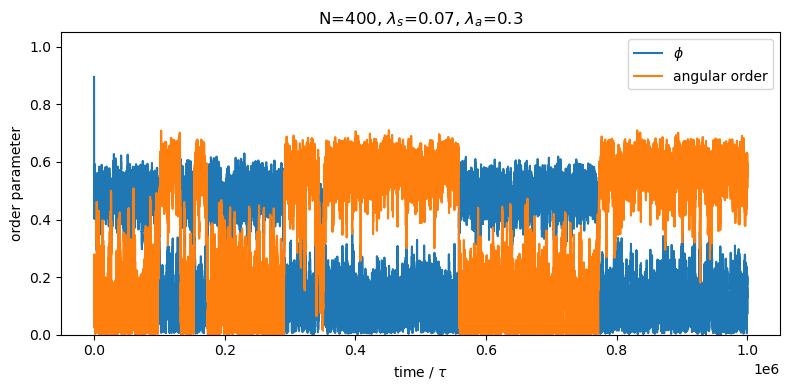

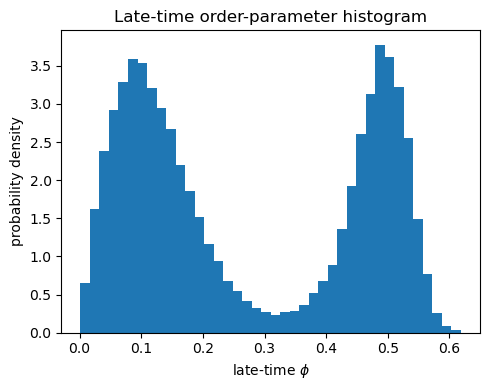

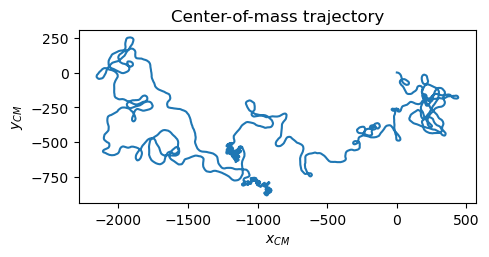

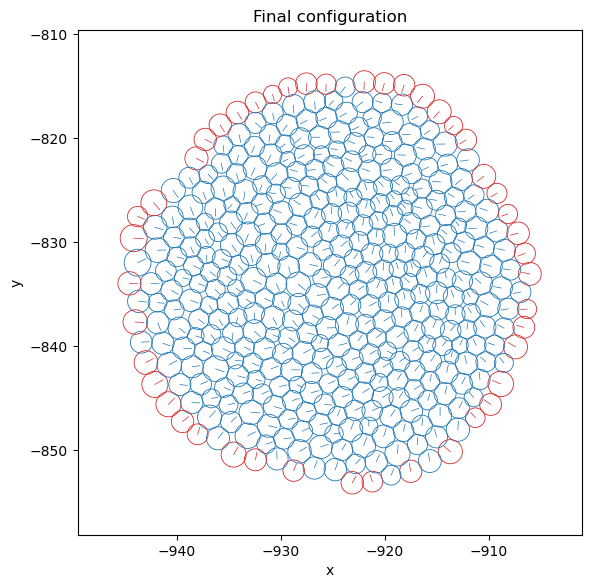

In [13]:
plot_summary(
    summary,
    title=fr"N={params.N}, $\lambda_s$={params.lambda_s}, $\lambda_a$={params.lambda_a}"
)

fig, ax = plt.subplots(figsize=(6, 6))
plot_snapshot(
    summary["final_positions"],
    summary["final_angles"],
    summary["radii"],
    summary["final_boundary"],
    ax=ax,
    title="Final configuration",
)
plt.tight_layout()
plt.show()

## 10. Paper reference runs

Use these two cases as sanity checks:

- `lambda_s = 0.07`, `lambda_a = 0.67`: mostly migrating.
- `lambda_s = 0.07`, `lambda_a = 0.30`: mixed / switching / rotating region.

For a quick comparison, use `steps = 500_000` or `1_000_000`. For a serious comparison, increase to `10_000_000` or more.

In [ ]:
reference_cases = [
    {"name": "mixed_switching_candidate", "lambda_s": 0.07, "lambda_a": 0.30, "seed": 3},
    {"name": "migrating_candidate", "lambda_s": 0.07, "lambda_a": 0.67, "seed": 3},
]

reference_results = []
reference_summaries = {}

for case in reference_cases:
    p = replace(
        params,
        lambda_s=case["lambda_s"],
        lambda_a=case["lambda_a"],
        seed=case["seed"],
    )
    print(f"Running {case['name']}: lambda_s={p.lambda_s}, lambda_a={p.lambda_a}")
    s = run_summary_only(p, progress_every=0)
    c = classify_state(s)
    reference_summaries[case["name"]] = s
    reference_results.append({"name": case["name"], "lambda_s": p.lambda_s, "lambda_a": p.lambda_a, **c})

reference_df = pd.DataFrame(reference_results)
reference_df

## 11. Summary-only parameter sweep

This sweep does not store full histories. That is essential for large runs.

Start with a small grid. Once you know which region is interesting, run longer simulations only there.

In [ ]:
def run_parameter_sweep_summary(
    base_params,
    lambda_s_values,
    lambda_a_values,
    seeds=(1,),
    keep_summaries=False,
    progress=False,
):
    results = []
    summaries = {}
    run_id = 0
    total_runs = len(lambda_s_values) * len(lambda_a_values) * len(seeds)

    for lambda_s in lambda_s_values:
        for lambda_a in lambda_a_values:
            for seed in seeds:
                p = replace(
                    base_params,
                    lambda_s=float(lambda_s),
                    lambda_a=float(lambda_a),
                    seed=int(seed),
                )

                print(
                    f"Run {run_id + 1}/{total_runs}: "
                    f"lambda_s={p.lambda_s:.3f}, lambda_a={p.lambda_a:.3f}, seed={p.seed}"
                )

                s = run_summary_only(p, progress_every=0)
                c = classify_state(s)

                row = {
                    "run_id": run_id,
                    "lambda_s": p.lambda_s,
                    "lambda_a": p.lambda_a,
                    "seed": p.seed,
                    "N": p.N,
                    "steps": p.steps,
                    "dt": p.dt,
                    "total_time": p.total_time,
                    **c,
                }
                results.append(row)

                if keep_summaries:
                    summaries[run_id] = s

                run_id += 1

    results_df = pd.DataFrame(results)
    if keep_summaries:
        return results_df, summaries
    return results_df

In [ ]:
# Small screening grid around the paper-relevant region.
lambda_s_values = np.array([0.04, 0.05, 0.06, 0.07, 0.08])
lambda_a_values = np.array([0.10, 0.20, 0.30, 0.45, 0.67, 1.00])

sweep_params = ModelParameters(
    N=400,
    steps=200_000,      # start here; increase interesting points later
    save_every=128,
    dt=0.1,
    lambda_n=0.03,
    lambda_Fin=0.3,
    lambda_Tin=3.0,
    seed=1,
)

results_df = run_parameter_sweep_summary(
    sweep_params,
    lambda_s_values,
    lambda_a_values,
    seeds=(1,),
    keep_summaries=False,
)

results_df

## 12. Plot sweep results

In [ ]:
def plot_sweep_heatmap(results_df, value, title=None):
    grid = results_df.pivot_table(
        index="lambda_s",
        columns="lambda_a",
        values=value,
        aggfunc="mean",
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(
        grid.values,
        origin="lower",
        aspect="auto",
        extent=[
            grid.columns.min(),
            grid.columns.max(),
            grid.index.min(),
            grid.index.max(),
        ],
    )
    ax.set_xlabel(r"alignment strength $\lambda_a$")
    ax.set_ylabel(r"self-propulsion strength $\lambda_s$")
    ax.set_title(title or value)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(value)
    plt.tight_layout()
    plt.show()


plot_sweep_heatmap(results_df, "mean_phi", title=r"Mean late-time orientational order $\phi$")
plot_sweep_heatmap(results_df, "mean_angular", title="Mean late-time angular order")
plot_sweep_heatmap(results_df, "std_phi", title=r"Late-time fluctuations in $\phi$")

In [ ]:
state_order = ["jammed/unclear", "rotating", "unclear/mixed", "mixed/switching", "migrating"]
state_to_number = {state: i for i, state in enumerate(state_order)}
number_to_state = {i: state for state, i in state_to_number.items()}

plot_df = results_df.copy()
plot_df["state_number"] = plot_df["state"].map(state_to_number)

state_grid = plot_df.pivot_table(
    index="lambda_s",
    columns="lambda_a",
    values="state_number",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    state_grid.values,
    origin="lower",
    aspect="auto",
    vmin=-0.5,
    vmax=len(state_order) - 0.5,
    extent=[
        state_grid.columns.min(),
        state_grid.columns.max(),
        state_grid.index.min(),
        state_grid.index.max(),
    ],
)
ax.set_xlabel(r"alignment strength $\lambda_a$")
ax.set_ylabel(r"self-propulsion strength $\lambda_s$")
ax.set_title("Screening classification")

cbar = plt.colorbar(im, ax=ax, ticks=np.arange(len(state_order)))
cbar.ax.set_yticklabels(state_order)
plt.tight_layout()
plt.show()

## 13. Rerun interesting points longer

After the screening sweep, select only the interesting points and increase `steps`. This is much more efficient than running the entire grid at paper length.

In [ ]:
interesting = results_df.sort_values(["std_phi", "mean_angular"], ascending=False).head(5)
interesting[["run_id", "lambda_s", "lambda_a", "state", "mean_phi", "std_phi", "mean_angular"]]

In [ ]:
long_results = []
long_summaries = {}

long_params_base = replace(
    sweep_params,
    steps=1_000_000,   # increase to 10_000_000 for final serious runs
    save_every=128,
    dt=0.1,
)

for _, row in interesting.iterrows():
    p = replace(
        long_params_base,
        lambda_s=float(row["lambda_s"]),
        lambda_a=float(row["lambda_a"]),
        seed=int(row["seed"]),
    )
    print(f"Long rerun: lambda_s={p.lambda_s}, lambda_a={p.lambda_a}, seed={p.seed}")
    s = run_summary_only(p, progress_every=100_000)
    c = classify_state(s)
    key = (p.lambda_s, p.lambda_a, p.seed)
    long_summaries[key] = s
    long_results.append({"lambda_s": p.lambda_s, "lambda_a": p.lambda_a, "seed": p.seed, **c})

long_results_df = pd.DataFrame(long_results)
long_results_df

## 14. Save compact results

This saves the sweep table and one selected summary in compact files. It does not save full trajectories.

In [ ]:
out_dir = Path("simulation_outputs")
out_dir.mkdir(exist_ok=True)

results_df.to_csv(out_dir / "summary_sweep_results.csv", index=False)
print(f"Saved: {out_dir / 'summary_sweep_results.csv'}")

# Save the current single-run summary as compressed arrays.
np.savez_compressed(
    out_dir / "single_run_summary.npz",
    time=summary["time"],
    phi=summary["phi"],
    angular_order=summary["angular_order"],
    center_of_mass=summary["center_of_mass"],
    rms_radius=summary["rms_radius"],
    final_positions=summary["final_positions"],
    final_angles=summary["final_angles"],
    radii=summary["radii"],
    final_boundary=summary["final_boundary"],
)
print(f"Saved: {out_dir / 'single_run_summary.npz'}")

## 15. Optional: make a short animation only after selecting a case

Long paper-style runs should not save full trajectories. For animations, rerun a selected parameter set for fewer steps and save snapshots occasionally.

This keeps the production sweep fast while still allowing you to make figures/videos.

In [ ]:
def run_with_sparse_snapshots(params: ModelParameters, snapshot_every=1_000, progress_every=0):
    """
    Simple Python wrapper around repeated summary runs is not used here because
    we need actual snapshots. This function is intentionally for short runs only.

    For final data, use run_summary_only().
    """
    # For simplicity and speed, use the summary core once and store only final state.
    # If you need actual animations, reduce steps strongly and adapt this function.
    print("For long simulations, do not animate. Rerun a short case in your original notebook if needed.")
    return run_summary_only(params, progress_every=progress_every)

## Recommended workflow

1. Run the benchmark cell.
2. Run one `N=400`, `steps=1_000_000`, `dt=0.1` summary-only simulation.
3. Run the screening sweep with `steps=200_000`.
4. Pick the interesting points using `std_phi`, `mean_phi`, and `mean_angular`.
5. Rerun only those points with `steps=1_000_000`, then `10_000_000` if needed.
6. Use the original animation notebook only for short visual examples, not for production sweeps.